<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/TQQQ_TLT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
!pip install --upgrade yfinance
!pip install  --upgrade pandas_ta
!pip install ta pandas_ta

In [76]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
import numpy as np
from datetime import datetime
import time
import ta
import matplotlib.pyplot as plt
print("Libraries Installed!")

0.2.66
Libraries Installed!


In [88]:
# Download data
tickers = ["TQQQ", "TLT"]
data = yf.download(tickers, start="2024-01-01", interval="1d",auto_adjust=True)["Close"]

# Compute returns
returns = data.pct_change()

# Lookback window (3 months ~ 63 trading days)
window = 63

# Inspect dataframe
data.head()

[*********************100%***********************]  2 of 2 completed


Ticker,TLT,TQQQ
Date,,
2024-01-02,91.730759,47.146385
2024-01-03,92.113319,45.637856
2024-01-04,90.713737,44.873795
2024-01-05,89.845955,45.040321
2024-01-08,90.732368,47.753708


In [89]:

def compute_relative_strength(prices, method="raw"):
    roc = prices.pct_change(window) # 3-month return

    if method == "raw":
        rs = roc
    elif method == "vol_adj":
        vol = returns.rolling(window).std() * np.sqrt(window)
        rs = roc / vol
    else:
        raise ValueError("Method must be 'raw' or 'vol_adj'")

    return rs


    # Compute signals
rs_raw = compute_relative_strength(data, method="raw")
rs_vol = compute_relative_strength(data, method="vol_adj")



In [92]:
# Resample monthly (take last available signal each month)
rs_raw_m = rs_raw.resample("ME").last()

#print("Relative strengths are :",rs_raw_m )
rs_raw_m.tail(10)

Ticker,TLT,TQQQ
Date,,
2024-12-31,-0.103760,0.143661
2025-01-31,-0.036126,0.079538
2025-02-28,0.007695,-0.043774
2025-03-31,0.043524,-0.348793
2025-04-30,0.027105,-0.329901
2025-05-31,-0.056776,-0.062914
2025-06-30,-0.010162,0.451558
2025-07-31,-0.017646,0.611824
2025-08-31,0.015069,0.280145


In [93]:
# Resample monthly (take last available signal each month)
rs_vol_m = rs_vol.resample("ME").last()
#print("Volatility normalized Relative strengths are :",rs_vol_m )
rs_vol_m.tail(10)

Ticker,TLT,TQQQ
Date,,
2024-12-31,-1.424742,0.561303
2025-01-31,-0.504467,0.275970
2025-02-28,0.117830,-0.152511
2025-03-31,0.690923,-1.059412
2025-04-30,0.342710,-0.583493
2025-05-31,-0.756814,-0.109824
2025-06-30,-0.131660,0.851610
2025-07-31,-0.291671,2.937019
2025-08-31,0.270170,1.553007


In [81]:
def generate_signals(rs):
    # Create a Series filled with 'CASH' for rows that are all NaN
    signals = pd.Series("CASH", index=rs.index)

    # Identify rows that are not all NaN
    valid_rows = rs.notna().any(axis=1)

    # For valid rows, pick the strongest asset
    signals.loc[valid_rows] = rs[valid_rows].idxmax(axis=1)

    # Apply volatility filter: go to CASH if max < 0
    signals.loc[rs.max(axis=1) < 0] = "CASH"

    return signals

signals_raw = generate_signals(rs_raw_m)
signals_vol = generate_signals(rs_vol_m)

# Strategy returns
monthly_returns = returns.resample("ME").apply(lambda x: (1+x).prod() - 1)

monthly_returns


Ticker,QQQ,TLT,TQQQ
Date,,,
2024-01-31,0.035719,-0.016784,0.093704
2024-02-29,0.052833,-0.022522,0.146657
2024-03-31,0.012750,0.007829,0.023561
2024-04-30,-0.043738,-0.064555,-0.143275
2024-05-31,0.061518,0.028870,0.185628
2024-06-30,0.064701,0.018171,0.185068
2024-07-31,-0.016781,0.036299,-0.075048
2024-08-31,0.011039,0.021112,0.004833
2024-09-30,0.026216,0.019994,0.059954


In [82]:
signals_vol.index[:-1]

signals_vol.loc['2025-09-30']

'QQQ'

In [86]:
def backtest(signals, cap_tqqq=False):
    strat_rets = []
    for date in signals.index[:-1]:
        asset = signals.loc[date]
        next_ret = monthly_returns.loc[date]

        if asset == "CASH":
            strat_rets.append(0)
        elif asset == "TQQQ" and cap_tqqq:
            strat_rets.append(0.7 * next_ret["TQQQ"]) # 50% cap
        #elif asset == "TQQQ":
            # Instead of 50% TQQQ + 50% cash
            #strat_rets.append(0.5 * next_ret["TQQQ"] + 0.5 * next_ret["QQQ"])
        else:
            strat_rets.append(next_ret[asset])

    return pd.Series(strat_rets, index=signals.index[:-1])

# Backtests
bt_raw = backtest(signals_raw, cap_tqqq=True)
bt_vol = backtest(signals_vol, cap_tqqq=True)

# Equity curves
equity_raw = (1 + bt_raw).cumprod()
equity_vol = (1 + bt_vol).cumprod()

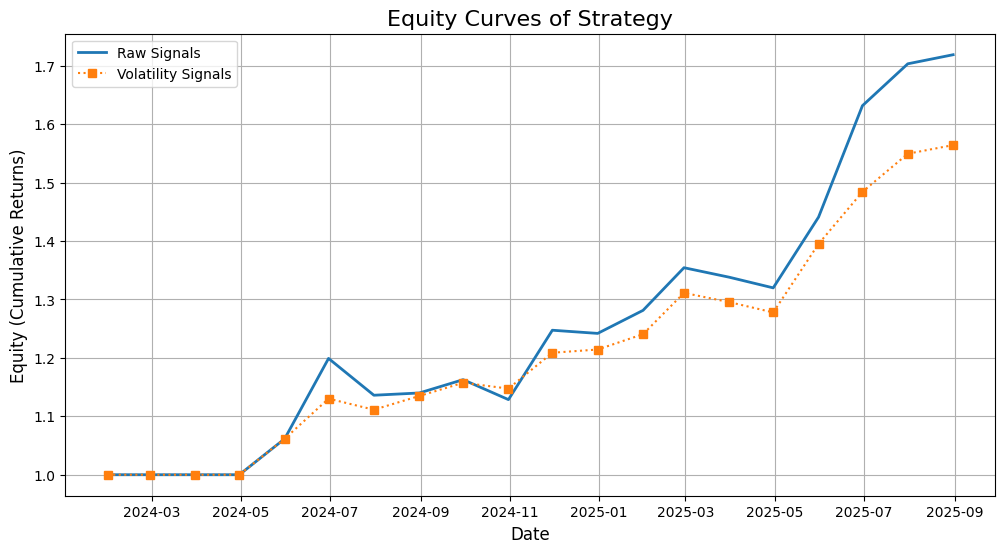

In [87]:

plt.figure(figsize=(12,6))

# Raw signals: solid line
plt.plot(equity_raw, label="Raw Signals", linewidth=2)

# Volatility signals: dotted line with square markers
plt.plot(
    equity_vol,
    label="Volatility Signals",
    linestyle=":",   # dotted line
    marker="s",     # square markers
    markersize=6,
    linewidth=1.5
)

plt.title("Equity Curves of Strategy", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Equity (Cumulative Returns)", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()



In [85]:


def evaluate_strategy(strategy_returns, periods_per_year=12, risk_free=0.0):
    """
    Evaluate a strategy's performance metrics.

    Parameters:
    - strategy_returns: pd.Series of returns (monthly or daily)
    - periods_per_year: 12 for monthly, 252 for daily
    - risk_free: annual risk-free rate (default 0)

    Returns:
    - pd.Series with key metrics
    """

    # Remove NaNs
    returns = strategy_returns.dropna()

    # Cumulative return
    cumulative = (1 + returns).prod() - 1

    # Annualized return
    ann_return = (1 + cumulative) ** (periods_per_year / len(returns)) - 1

    # Annualized volatility
    ann_vol = returns.std() * np.sqrt(periods_per_year)

    # Sharpe ratio
    sharpe = (ann_return - risk_free) / ann_vol if ann_vol != 0 else np.nan

    # Equity curve & drawdowns
    equity = (1 + returns).cumprod()
    drawdown = equity / equity.cummax() - 1
    max_dd = drawdown.min()

    # Calmar ratio
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    # Sortino ratio
    downside_std = returns[returns < 0].std() * np.sqrt(periods_per_year)
    sortino = (ann_return - risk_free) / downside_std if downside_std != 0 else np.nan

    # Win rate / hit ratio
    win_rate = (returns > 0).mean()

    metrics = {
        "Cumulative Return": cumulative,
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd,
        "Calmar Ratio": calmar,
        "Sortino Ratio": sortino,
        "Hit Ratio": win_rate
    }

    return pd.Series(metrics)

# Example usage
metrics_raw = evaluate_strategy(bt_raw)
metrics_vol = evaluate_strategy(bt_vol)

# Combine into one table
metrics_comparison = pd.DataFrame({
    "Raw RS": metrics_raw,
    "Volatility-Weighted RS": metrics_vol
})

metrics_comparison


,Raw RS,Volatility-Weighted RS
Cumulative Return,0.965626,0.592354
Annualized Return,0.500032,0.321977
Annualized Volatility,0.245730,0.115365
Sharpe Ratio,2.034882,2.790950
Max Drawdown,-0.091750,-0.025488
Calmar Ratio,5.449923,12.632627
Sortino Ratio,5.004293,27.482435
Hit Ratio,0.550000,0.600000
